In [1]:
# !pip install deepxde

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 4.9 MB/s eta 0:00:0000:01


In [2]:
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt

dde.config.set_default_float("float64")


No backend selected.
Finding available backend...
2026-05-28 04:07:54.427681: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779941274.853683      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779941274.970191      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779941275.980370      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779941275.980419      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779941275.980422      58

Setting the default backend to "tensorflow". You can change it in the ~/.deepxde/config.json file or export the DDE_BACKEND environment variable. Valid options are: tensorflow.compat.v1, tensorflow, pytorch, jax, paddle (all lowercase)


Enable just-in-time compilation with XLA.



Set the default float type to float64


## Diffusion Equation
$$\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}$$

In [3]:
def diffusion_pde(x, u):
    du_dt = dde.grad.jacobian(u, x, i=0, j=1)
    du_dx2 = dde.grad.hessian(u, x, i=0, j=0)
    return du_dt - (0.4*du_dx2)

### Interval Defining

In [4]:
time = dde.geometry.TimeDomain(0, 5)
space = dde.geometry.Interval(-5, 5)
geom = dde.geometry.GeometryXTime(space, time)

### Initial and Boundary Condition

In [5]:
bc = dde.icbc.DirichletBC(
    geom, 
    lambda x: 0, 
    lambda _, on_boundary: on_boundary
)
ic = dde.icbc.IC(
    geom,
    lambda x: np.sin(np.pi * x[:, 0:1]),
    lambda _, on_initial: on_initial
)

In [6]:
exact = lambda x: (np.exp(-0.4 * np.pi**2 * x[:, 1:2])
                    * np.sin(np.pi * x[:, 0:1]))

In [7]:
data = dde.data.TimePDE(
    geom,
    diffusion_pde,
    [bc, ic],
    num_domain=3000,
    num_boundary=400,
    num_initial=400,
    solution=exact,
)

net = dde.nn.FNN([2] + [64] * 4 + [1], "tanh", "Glorot normal")
model = dde.Model(data, net)

In [8]:
model.compile("adam", lr=1e-3)
model.train(iterations=10000)
model.compile("L-BFGS")
model.train()

Compiling model...
'compile' took 0.500469 s

Training model...



I0000 00:00:1779941301.847195      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779941301.853348      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Cause: could not parse the source code of <function <lambda> at 0x78b40936a980>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the source code of <function <lambda> at 0x78b40936a980>: no matching AST found among candidates:
# coding=utf-8
lambda x, on: np.array([on_boundary(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary1(x[i], on[i]) for i in range(len(x))])
# coding=utf-8
lambda x, on: np.array([on_boundary2(x[i], on[i]) for i in range(len(x))])
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Cause: could not parse the sourc

I0000 00:00:1779941306.163956      58 service.cc:152] XLA service 0x20df9500 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779941306.164013      58 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779941306.164020      58 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779941306.425452      58 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1779941307.343855      58 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Step      Train loss                        Test loss                         Test metric
0         [4.90e-02, 1.61e-01, 5.06e-01]    [4.90e-02, 1.61e-01, 5.06e-01]    []  
1000      [6.86e-03, 1.66e-03, 3.08e-01]    [6.86e-03, 1.66e-03, 3.08e-01]    []  
2000      [1.35e-02, 8.08e-03, 6.86e-02]    [1.35e-02, 8.08e-03, 6.86e-02]    []  
3000      [2.12e-03, 6.22e-04, 5.86e-04]    [2.12e-03, 6.22e-04, 5.86e-04]    []  
4000      [6.13e-04, 1.28e-04, 6.79e-05]    [6.13e-04, 1.28e-04, 6.79e-05]    []  
5000      [2.50e-04, 2.43e-05, 2.09e-05]    [2.50e-04, 2.43e-05, 2.09e-05]    []  
6000      [5.08e-04, 1.16e-04, 2.87e-04]    [5.08e-04, 1.16e-04, 2.87e-04]    []  
7000      [9.33e-05, 4.38e-06, 8.78e-06]    [9.33e-05, 4.38e-06, 8.78e-06]    []  
8000      [3.02e-04, 4.49e-04, 1.04e-03]    [3.02e-04, 4.49e-04, 1.04e-03]    []  
9000      [2.57e-04, 4.82e-04, 7.37e-04]    [2.57e-04, 4.82e-04, 7.37e-04]    []  
10000     [5.39e-05, 1.02e-06, 5.06e-06]    [5.39e-05, 1.02e-06, 5.06e-06]    []

(<deepxde.model.LossHistory at 0x78b4097bb440>,
 <deepxde.model.TrainState at 0x78b53ec2e2d0>)

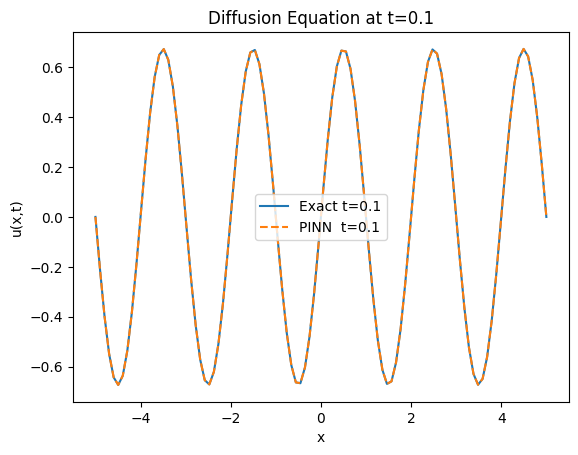

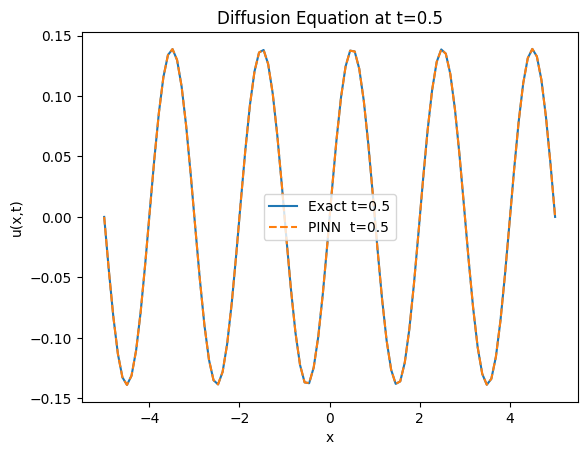

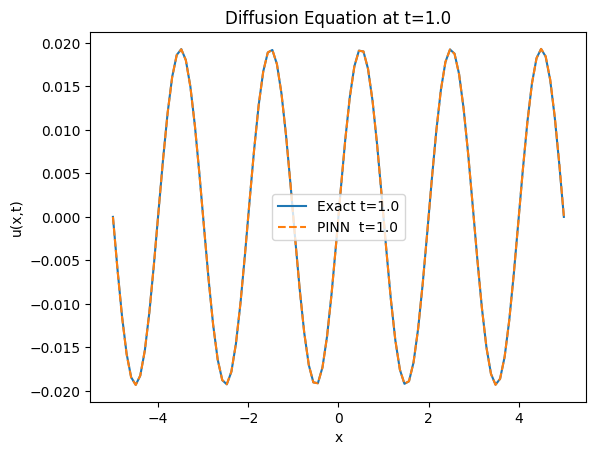

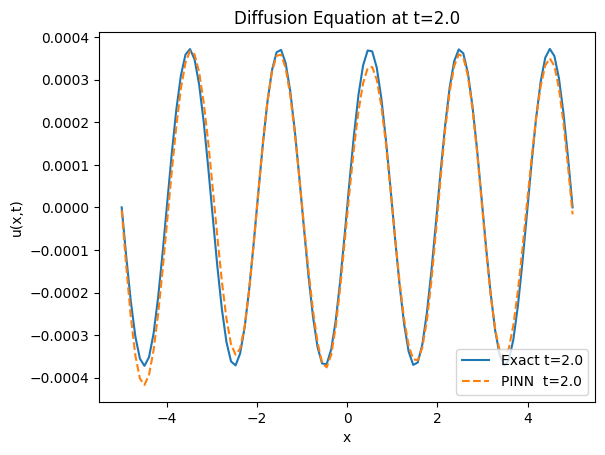

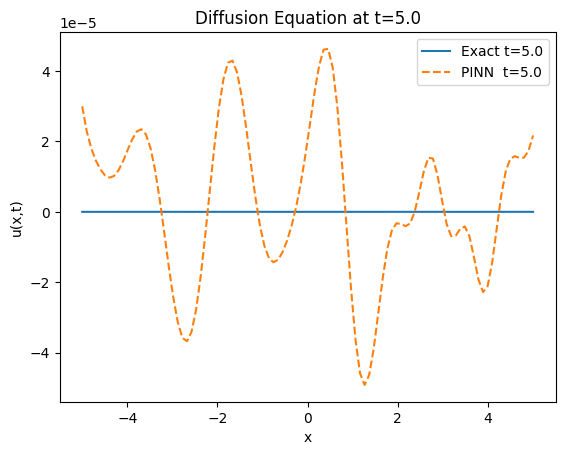

In [9]:
x = np.linspace(-5, 5, 100)
for t in [0.1, 0.5, 1.0, 2.0, 5.0]:
    xt = np.column_stack([x, np.full_like(x, t)])
    solution = model.predict(xt).flatten()
    u_ex   = (np.exp(-0.4 * np.pi**2 * t)
              * np.sin(np.pi * x))
    plt.plot(x, u_ex,   label=f"Exact t={t}")
    plt.plot(x, solution, "--", label=f"PINN  t={t}")
    plt.title(f"Diffusion Equation at t={t}")
    plt.xlabel("x")
    plt.ylabel("u(x,t)")
    plt.legend()
    plt.show()
